In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
areas = pd.read_csv("driver_area.csv")

In [23]:
vehicles = pd.read_csv("vehicle_stats.csv")
characters = pd.read_csv("character_stats.csv")

In [24]:
characters = characters.merge(areas, how="outer", on="Name")

In [27]:
combos = characters.assign(key=1).merge(vehicles.assign(key=1), on="key").drop("key", axis=1)
combos.columns = [
    "Character", "Char_Category", "Char_Acceleration", "Char_Handling", "Char_Speed", "Char_Weight",
    "Char_Area", "Vehicle", "Veh_Category", "Veh_Acceleration", "Veh_Handling", "Veh_Speed", "Veh_Weight"
]

combos["Acceleration"] = combos["Char_Acceleration"] + combos["Veh_Acceleration"]
combos["Handling"] = combos["Char_Handling"] + combos["Veh_Handling"]
combos["Speed"] = combos["Char_Speed"] + combos["Veh_Speed"]
combos["Weight"] = combos["Char_Weight"] + combos["Veh_Weight"]
combos["Frontal Area"] = combos["Char_Area"]

result = combos[["Character", "Vehicle", "Acceleration", "Handling", "Speed", "Weight", "Frontal Area"]].copy()
result

,Character,Vehicle,Acceleration,Handling,Speed,Weight,Frontal Area
0,Baby Daisy,Tune Thumper,18,15,3,4,3
1,Baby Daisy,Standard Bike,18,15,3,4,3
2,Baby Daisy,Cute Scoot,18,15,3,4,3
3,Baby Daisy,Rally Bike,17,15,4,4,3
4,Baby Daisy,Pipe Frame,17,14,4,5,3
...,...,...,...,...,...,...,...
1955,Yoshi,Mecha Trike,8,9,12,11,5
1956,Yoshi,Li'l Dumpy,8,9,12,11,5
1957,Yoshi,Chargin' Truck,8,9,12,11,5
1958,Yoshi,Bowser Bruiser,8,9,12,11,5


In [30]:
def terminal_vel(a, m, A, v, B, p = 1.225, d = 100):
    c = drag_coefficient(a,m,p,A,v,B,d)
    v_t = math.sqrt((v*m*a) / (p * (A+35) * c))
    return v_t

In [31]:
import math

def drag_coefficient(a,m,p,A,v,B,d):
    coeff = (m/(m+1))*(1-0.3*math.exp(-1*B*d))
    return coeff

In [45]:
result.loc[:, 'v_t @ d=inf'] = result.apply(lambda row: terminal_vel(
    a=row['Acceleration'], 
    m=row['Weight']*10, 
    A=row['Frontal Area'], 
    v=row['Speed'], 
    B=0.24), axis=1)

result.loc[:, 'v_t @ d=1'] = result.apply(lambda row: terminal_vel(
    a=row['Acceleration'], 
    m=row['Weight']*10, 
    A=row['Frontal Area'], 
    v=row['Speed'], 
    B=0.24, d=1), axis=1)

result.loc[:, 'v_t @ d=0.5'] = result.apply(lambda row: terminal_vel(
    a=row['Acceleration'], 
    m=row['Weight']*10, 
    A=row['Frontal Area'], 
    v=row['Speed'], 
    B=0.24, d=0.5), axis=1)

result.loc[:, 'v_t @ d=0.25'] = result.apply(lambda row: terminal_vel(
    a=row['Acceleration'], 
    m=row['Weight']*10, 
    A=row['Frontal Area'], 
    v=row['Speed'], 
    B=0.24, d=0.25), axis=1)

result.loc[:, 'v_t @ d=0.1'] = result.apply(lambda row: terminal_vel(
    a=row['Acceleration'], 
    m=row['Weight']*10, 
    A=row['Frontal Area'], 
    v=row['Speed'], 
    B=0.24, d=0.1), axis=1)

result.loc[:, 'v_t_0.1 / v_t_inf'] = result['v_t @ d=0.1']/result['v_t @ d=inf']
result.loc[:, 'v_t_0.1 - v_t_inf'] = result['v_t @ d=0.1']-result['v_t @ d=inf']
result
filtered_df = result.iloc[:10, np.r_[0:2, 7:14]]
filtered_df

,Character,Vehicle,v_t @ d=inf,v_t @ d=1,v_t @ d=0.5,v_t @ d=0.25,v_t @ d=0.1,v_t_0.1 / v_t_inf,v_t_0.1 - v_t_inf
0,Baby Daisy,Tune Thumper,6.896504,7.890036,8.050140,8.141921,8.201328,1.189201,1.304824
1,Baby Daisy,Standard Bike,6.896504,7.890036,8.050140,8.141921,8.201328,1.189201,1.304824
2,Baby Daisy,Cute Scoot,6.896504,7.890036,8.050140,8.141921,8.201328,1.189201,1.304824
3,Baby Daisy,Rally Bike,7.739030,8.853940,9.033604,9.136597,9.203261,1.189201,1.464231
4,Baby Daisy,Pipe Frame,8.631369,9.874832,10.075212,10.190081,10.264431,1.189201,1.633062
5,Baby Daisy,Hyper Pipe,7.739030,8.853940,9.033604,9.136597,9.203261,1.189201,1.464231
6,Baby Daisy,Fin Twin,7.739030,8.853940,9.033604,9.136597,9.203261,1.189201,1.464231
7,Baby Daisy,Dolphin Dasher,7.739030,8.853940,9.033604,9.136597,9.203261,1.189201,1.464231
8,Baby Daisy,R.O.B. H.O.G.,8.394157,9.603446,9.798319,9.910031,9.982338,1.189201,1.588181
9,Baby Daisy,Mach Rocket,8.394157,9.603446,9.798319,9.910031,9.982338,1.189201,1.588181


In [79]:
most_optimal_combos = result.sort_values(by=['v_t_0.1 / v_t_inf', 'v_t_0.1 - v_t_inf'], ascending=False).reset_index(drop=True)
least_optimal_combos = result.sort_values(by=['v_t_0.1 / v_t_inf', 'v_t_0.1 - v_t_inf'], ascending=True).reset_index(drop=True)
most_optimal_combos.iloc[:10]
least_optimal_combos.iloc[:10]
matching_rows = most_optimal_combos[most_optimal_combos['Character'] == 'Toadette']
matching_rows

,Character,Vehicle,Acceleration,Handling,Speed,Weight,Frontal Area,v_t @ d=inf,v_t @ d=1,v_t @ d=0.5,v_t @ d=0.25,v_t @ d=0.1,v_t_0.1 / v_t_inf,v_t_0.1 - v_t_inf
37,Toadette,Billdozer,10,10,10,10,4,14.539864,16.634523,16.972071,17.165572,17.290818,1.189201,2.750954
38,Toadette,Big Horn,10,10,10,10,4,14.539864,16.634523,16.972071,17.165572,17.290818,1.189201,2.750954
64,Toadette,Tiny Titan,9,10,11,10,4,14.466982,16.551141,16.886997,17.079528,17.204146,1.189201,2.737165
65,Toadette,Mecha Trike,9,10,11,10,4,14.466982,16.551141,16.886997,17.079528,17.204146,1.189201,2.737165
66,Toadette,Li'l Dumpy,9,10,11,10,4,14.466982,16.551141,16.886997,17.079528,17.204146,1.189201,2.737165
67,Toadette,Chargin' Truck,9,10,11,10,4,14.466982,16.551141,16.886997,17.079528,17.204146,1.189201,2.737165
68,Toadette,Bowser Bruiser,9,10,11,10,4,14.466982,16.551141,16.886997,17.079528,17.204146,1.189201,2.737165
184,Toadette,Rallygator,11,8,10,11,4,15.986651,18.289738,18.660874,18.873629,19.011338,1.189201,3.024687
185,Toadette,Lobster Roller,10,8,11,11,4,15.986651,18.289738,18.660874,18.873629,19.011338,1.189201,3.024687
326,Toadette,Junkyard Hog,11,9,11,9,4,15.181442,17.368529,17.720972,17.923011,18.053783,1.189201,2.872341


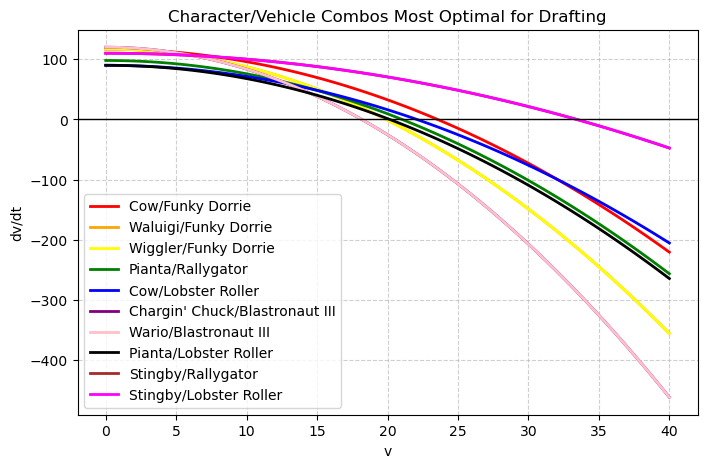

In [66]:
x = np.linspace(0, 40, 100) 

def C(m, B, d):
    return (m/(m+1))*(1-0.4*(math.exp(-0.1*B*d)))

def f(x, m, v, a, B, A, d = 100, p = 1.225):
    c = C(m, B, d)
    return (1/m)*((m*v*a)-(0.5*p*A*c*(x**2)))

y = []
for i in range(10):
    y.append(f(x, most_optimal_combos.iloc[i]['Weight'],
               most_optimal_combos.iloc[i]['Speed'],
               most_optimal_combos.iloc[i]['Acceleration'], 
               0.24, 
               most_optimal_combos.iloc[i]['Frontal Area']))

plt.figure(figsize=(8, 5))
plt.plot(x, y[0], label=most_optimal_combos.iloc[0]['Character'] + "/" + most_optimal_combos.iloc[0]['Vehicle'], color='red', linewidth=2)
plt.plot(x, y[1], label=most_optimal_combos.iloc[1]['Character'] + "/" + most_optimal_combos.iloc[1]['Vehicle'], color='orange', linewidth=2)
plt.plot(x, y[2], label=most_optimal_combos.iloc[2]['Character'] + "/" + most_optimal_combos.iloc[2]['Vehicle'], color='yellow', linewidth=2)
plt.plot(x, y[3], label=most_optimal_combos.iloc[3]['Character'] + "/" + most_optimal_combos.iloc[3]['Vehicle'], color='green', linewidth=2)
plt.plot(x, y[4], label=most_optimal_combos.iloc[4]['Character'] + "/" + most_optimal_combos.iloc[4]['Vehicle'], color='blue', linewidth=2)
plt.plot(x, y[5], label=most_optimal_combos.iloc[5]['Character'] + "/" + most_optimal_combos.iloc[5]['Vehicle'], color='purple', linewidth=2)
plt.plot(x, y[6], label=most_optimal_combos.iloc[6]['Character'] + "/" + most_optimal_combos.iloc[6]['Vehicle'], color='pink', linewidth=2)
plt.plot(x, y[7], label=most_optimal_combos.iloc[7]['Character'] + "/" + most_optimal_combos.iloc[7]['Vehicle'], color='black', linewidth=2)
plt.plot(x, y[8], label=most_optimal_combos.iloc[8]['Character'] + "/" + most_optimal_combos.iloc[8]['Vehicle'], color='brown', linewidth=2)
plt.plot(x, y[9], label=most_optimal_combos.iloc[9]['Character'] + "/" + most_optimal_combos.iloc[9]['Vehicle'], color='magenta', linewidth=2)

plt.title('Character/Vehicle Combos Most Optimal for Drafting')
plt.xlabel('v')
plt.ylabel('dv/dt')
plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.savefig('best.png')
plt.show()

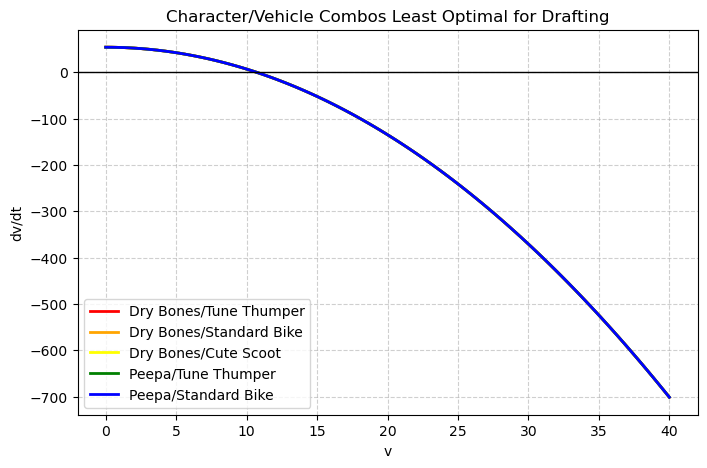

In [76]:
z = []
for i in range(10):
    z.append(f(x, least_optimal_combos.iloc[i]['Weight'],
               least_optimal_combos.iloc[i]['Speed'],
               least_optimal_combos.iloc[i]['Acceleration'], 
               0.24, 
               least_optimal_combos.iloc[i]['Frontal Area']))

plt.figure(figsize=(8, 5))
plt.plot(x, z[0], label=least_optimal_combos.iloc[0]['Character'] + "/" + least_optimal_combos.iloc[0]['Vehicle'], color='red', linewidth=2)
plt.plot(x, z[1], label=least_optimal_combos.iloc[1]['Character'] + "/" + least_optimal_combos.iloc[1]['Vehicle'], color='orange', linewidth=2)
plt.plot(x, z[2], label=least_optimal_combos.iloc[2]['Character'] + "/" + least_optimal_combos.iloc[2]['Vehicle'], color='yellow', linewidth=2)
plt.plot(x, z[3], label=least_optimal_combos.iloc[3]['Character'] + "/" + least_optimal_combos.iloc[3]['Vehicle'], color='green', linewidth=2)
plt.plot(x, z[4], label=least_optimal_combos.iloc[4]['Character'] + "/" + least_optimal_combos.iloc[4]['Vehicle'], color='blue', linewidth=2)
#plt.plot(x, z[5], label=least_optimal_combos.iloc[5]['Character'] + "/" + least_optimal_combos.iloc[5]['Vehicle'], color='purple', linewidth=2)
#plt.plot(x, z[6], label=least_optimal_combos.iloc[6]['Character'] + "/" + least_optimal_combos.iloc[6]['Vehicle'], color='pink', linewidth=2)
#plt.plot(x, y[7], label=least_optimal_combos.iloc[7]['Character'] + "/" + least_optimal_combos.iloc[7]['Vehicle'], color='black', linewidth=2)
#plt.plot(x, z[8], label=least_optimal_combos.iloc[8]['Character'] + "/" + least_optimal_combos.iloc[8]['Vehicle'], color='brown', linewidth=2)
#plt.plot(x, z[9], label=least_optimal_combos.iloc[9]['Character'] + "/" + least_optimal_combos.iloc[9]['Vehicle'], color='magenta', linewidth=2)

plt.title('Character/Vehicle Combos Least Optimal for Drafting')
plt.xlabel('v')
plt.ylabel('dv/dt')
plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.savefig('worst.png')
plt.show()

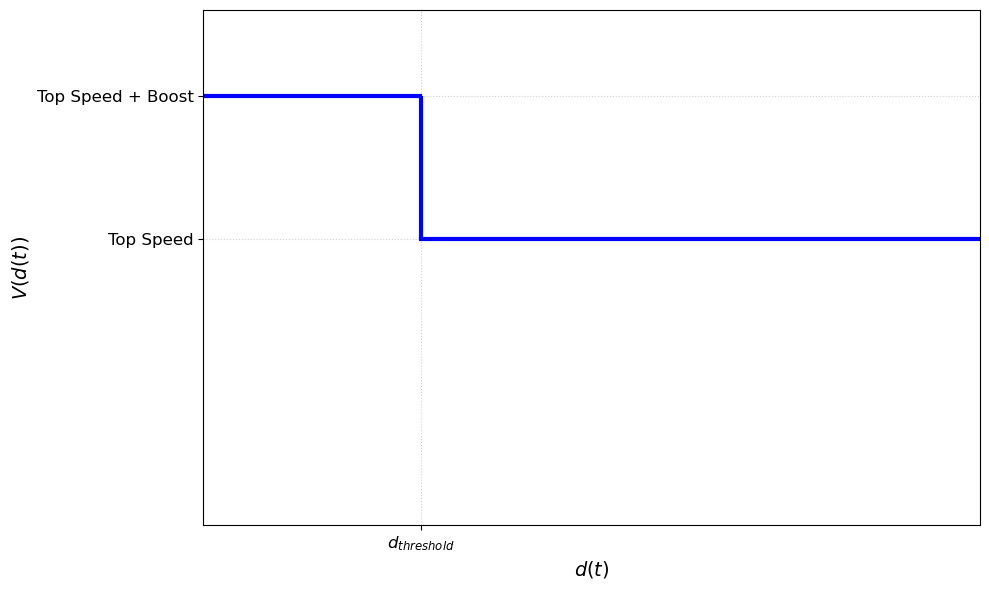

In [6]:
import matplotlib.pyplot as plt
import numpy as np

v_top = 10
v_boost = 5
d_thresh = 7
d_max = 25

d = np.linspace(0, d_max, 1000)

v = np.where(d <= d_thresh, v_top + v_boost, v_top)

plt.figure(figsize=(10, 6))

plt.plot(d[d <= d_thresh], v[d <= d_thresh], color='blue', linewidth=3)
plt.plot(d[d > d_thresh], v[d > d_thresh], color='blue', linewidth=3)
plt.vlines(d_thresh, v_top, v_top + v_boost, colors='blue', linewidth=3)

plt.xticks([d_thresh], ['$d_{threshold}$'], fontsize=12)
plt.yticks([v_top, v_top + v_boost], ['Top Speed', 'Top Speed + Boost'], fontsize=12)

plt.xlabel('$d(t)$', fontsize=14)
plt.ylabel('$V(d(t))$', fontsize=14)
plt.title('', fontsize=16)

plt.xlim(0, d_max)
plt.ylim(0, v_top + v_boost + 3)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('v(t).png')
plt.show()

<>:27: SyntaxWarning: invalid escape sequence '\d'
<>:28: SyntaxWarning: invalid escape sequence '\d'
<>:29: SyntaxWarning: invalid escape sequence '\d'
<>:27: SyntaxWarning: invalid escape sequence '\d'
<>:28: SyntaxWarning: invalid escape sequence '\d'
<>:29: SyntaxWarning: invalid escape sequence '\d'
/var/folders/nw/d1gmmz2561q6hf_lsr75ys740000gn/T/ipykernel_36091/1968351296.py:27: SyntaxWarning: invalid escape sequence '\d'
  plt.xlabel('Velocity $\dot{x}_f$')
/var/folders/nw/d1gmmz2561q6hf_lsr75ys740000gn/T/ipykernel_36091/1968351296.py:28: SyntaxWarning: invalid escape sequence '\d'
  plt.ylabel('Acceleration $\ddot{x}_f$')
/var/folders/nw/d1gmmz2561q6hf_lsr75ys740000gn/T/ipykernel_36091/1968351296.py:29: SyntaxWarning: invalid escape sequence '\d'
  plt.title('Phase Portrait for $\ddot{x}_f$ vs $\dot{x}_f$')


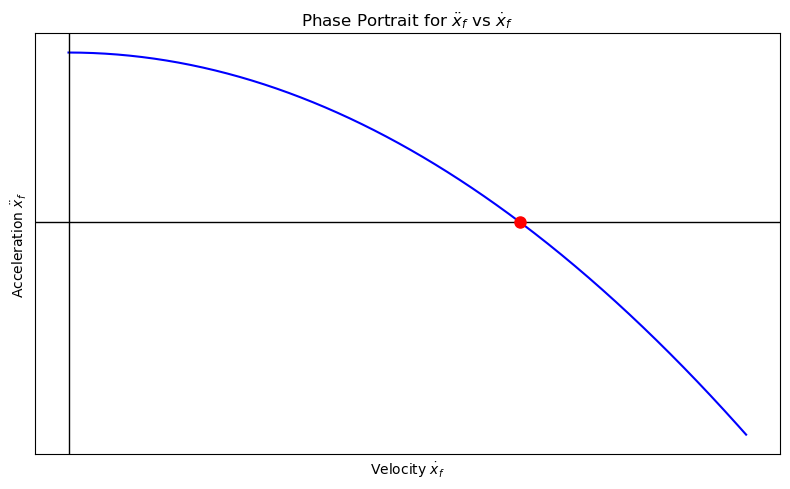

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Physical parameters
F = 50.0   # Engine force (N)
m = 10.0   # Mass (kg)
B = 0.1    # Drag coefficient (kg/m)

# Calculate fixed point (Terminal Velocity)
# At terminal velocity, acceleration is zero: 0 = F/m - B*v^2
v_star = np.sqrt(F / (m * B))

# 1. Create Phase Line Data (Acceleration v_dot vs Velocity v)
v_values = np.linspace(0, v_star * 1.5, 500)
v_dot_values = F/m - B * v_values**2

# 3. Plotting the results
plt.figure(figsize=(8, 5))

# Plot A: Phase Line Analysis
plt.plot(v_values, v_dot_values, 'b-', label=r'$\dot{v} = \frac{F}{m} - Bv^2$')
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.plot(v_star, 0, 'ro', markersize=8, label=f'Fixed Point ($v^* \\approx {v_star:.2f}$ m/s)')

# Labeling
plt.xlabel('Velocity $\dot{x}_f$')
plt.ylabel('Acceleration $\ddot{x}_f$')
plt.title('Phase Portrait for $\ddot{x}_f$ vs $\dot{x}_f$')

# --- REMOVE TALLY MARKS AND NUMBERS ---
plt.xticks([])
plt.yticks([])
# --------------------------------------

plt.grid(True, linestyle=':')
plt.tight_layout()
plt.savefig('phase_portrait.png')
plt.show()

<>:38: SyntaxWarning: invalid escape sequence '\d'
<>:38: SyntaxWarning: invalid escape sequence '\d'
/var/folders/nw/d1gmmz2561q6hf_lsr75ys740000gn/T/ipykernel_36091/1929440081.py:38: SyntaxWarning: invalid escape sequence '\d'
  plt.ylabel('Acceleration $\dot{v}$ (m/s$^2$)')


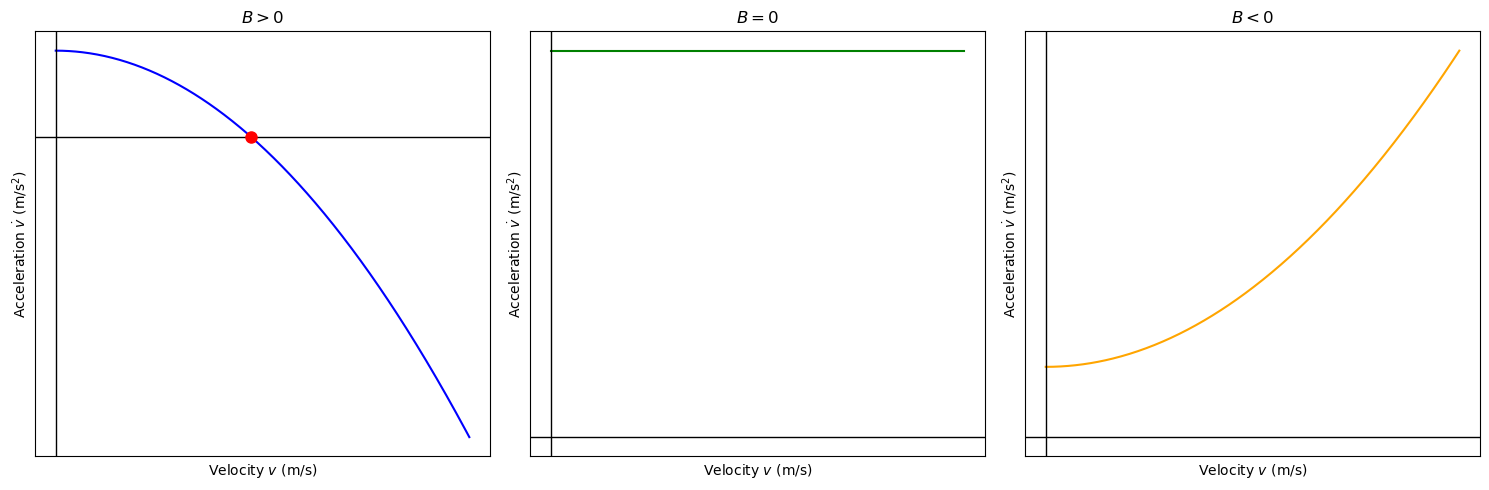

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define physical constants for all karts
F = 50.0   # Engine force (Newtons)
m = 10.0   # Mass of the kart (kg)
v_range = np.linspace(0, 15, 500)  # Standard velocity range for comparison

# 2. Define the three scenarios for B
B_values = [0.1, 0.0, -0.1]
titles = [r'$B > 0$', r'$B = 0$', r'$B < 0$']
colors = ['blue', 'green', 'orange']

# 3. Create a 1x3 layout for the subplots
plt.figure(figsize=(15, 5))

for i, B in enumerate(B_values):
    plt.subplot(1, 3, i + 1)
    
    # Calculate acceleration: v_dot = F/m - B*v^2
    v_dot = (F / m) - (B * v_range**2)
    
    # Plot the resulting acceleration curve
    plt.plot(v_range, v_dot, color=colors[i], label=f'Drag B = {B}')
    
    # Draw horizontal and vertical axes lines
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    
    # Add a fixed point (Terminal Velocity) only for the stable case (B > 0)
    if B > 0:
        v_star = np.sqrt(F / (m * B))
        plt.plot(v_star, 0, 'ro', markersize=8, label=f'Top Speed ($v^*$)')
    
    # Labeling and Formatting
    plt.xlabel('Velocity $v$ (m/s)')

    plt.ylabel('Acceleration $\dot{v}$ (m/s$^2$)')
    plt.title(titles[i])
    
    # --- REMOVE TALLY MARKS (TICKS) ---
    plt.xticks([])
    plt.yticks([])
    # ----------------------------------
    
    plt.grid(True, linestyle=':')

plt.tight_layout()
plt.savefig('vary_B.png')
plt.show()